In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import precision_recall_curve, average_precision_score
from tensorflow import keras
from tensorflow.keras import layers

X_train=pd.read_csv("../data/processed/X_train.csv")
X_test=pd.read_csv("../data/processed/X_test.csv")
y_train=pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test=pd.read_csv("../data/processed/y_test.csv").squeeze()

print(X_train.shape,X_test.shape)

/Users/abhyanshu/coding5thsem/fraud_detection/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


(227845, 30) (56962, 30)


In [2]:


iso_forest=IsolationForest(
    n_estimators=100,
    contamination=0.0017,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train)



IsolationForest(contamination=0.0017, n_jobs=-1, random_state=42)

In [3]:
raw_pred=iso_forest.predict(X_test)
y_pred=pd.Series(raw_pred).map({1:0,-1:1})
#print(y_test.value_counts())

print(y_pred.value_counts())

0    56856
1      106
Name: count, dtype: int64


In [4]:
scores=iso_forest.decision_function(X_test)
print(scores[:10])


[0.24822787 0.17741604 0.1166058  0.29544271 0.19472647 0.28372283
 0.25046909 0.27805331 0.28351095 0.28041984]


In [5]:


print("confusion matrix ",confusion_matrix(y_pred,y_test))
print(classification_report(y_pred,y_test))

confusion matrix  [[56791    65]
 [   73    33]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56856
           1       0.34      0.31      0.32       106

    accuracy                           1.00     56962
   macro avg       0.67      0.66      0.66     56962
weighted avg       1.00      1.00      1.00     56962



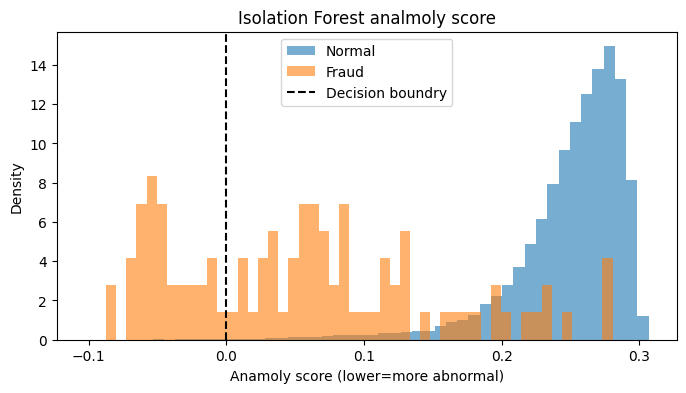

In [6]:

plt.figure(figsize=(8,4))
plt.hist(scores[y_test==0],bins=50,alpha=0.6,label="Normal",density="True")
plt.hist(scores[y_test==1],bins=50,alpha=0.6,label="Fraud",density="True")
plt.axvline(0,color="black",linestyle="--",label="Decision boundry")
plt.legend()
plt.title("Isolation Forest analmoly score")
plt.xlabel("Anamoly score (lower=more abnormal)")
plt.ylabel("Density")
plt.show()

In [7]:


lof=LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.0017,
    n_jobs=-1
)

lof.fit(X_train)

LocalOutlierFactor(contamination=0.0017, n_jobs=-1)

In [8]:
raw_pred_lof=lof.fit_predict(X_test)
y_pred_lof=pd.Series(raw_pred_lof).map({1:0,-1:1})
print(y_pred_lof.value_counts())

0    56865
1       97
Name: count, dtype: int64


In [9]:
print(confusion_matrix(y_pred_lof,y_test))
print(classification_report(y_pred_lof,y_test))

[[56769    96]
 [   95     2]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56865
           1       0.02      0.02      0.02        97

    accuracy                           1.00     56962
   macro avg       0.51      0.51      0.51     56962
weighted avg       1.00      1.00      1.00     56962



In [10]:
scores_lof = lof.negative_outlier_factor_
print(scores_lof[:10])

[-0.9937598  -1.20300227 -1.55834381 -0.9751231  -1.00760163 -1.43642041
 -1.22028531 -1.22362219 -0.99225999 -1.02983536]


In [11]:
for k in [5,10,20,35,50]:
    lof_test=LocalOutlierFactor(n_neighbors=k,contamination=0.0017,n_jobs=-1)
    pred=lof_test.fit_predict(X_test)
    pred_final=pd.Series(pred).map({1:0,-1:1})
    tp=((pred_final==1)&(y_test)==1).sum()
    print(f"for n_neighbors ={k} :caught {tp} out of 106")

for n_neighbors =5 :caught 0 out of 106
for n_neighbors =10 :caught 0 out of 106
for n_neighbors =20 :caught 2 out of 106
for n_neighbors =35 :caught 2 out of 106
for n_neighbors =50 :caught 6 out of 106


In [12]:

rf=RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [13]:
y_pred_rf=rf.predict(X_test)

print(confusion_matrix(y_pred_rf,y_test))
print(classification_report(y_pred_rf,y_test))

[[56861    25]
 [    3    73]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56886
           1       0.74      0.96      0.84        76

    accuracy                           1.00     56962
   macro avg       0.87      0.98      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [14]:
scores_rf = rf.predict_proba(X_test)[:, 1]
print(scores_rf[:10])

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [15]:
print(confusion_matrix(y_test, y_pred_rf))
print()
print(classification_report(y_test, y_pred_rf, digits=3))

[[56861     3]
 [   25    73]]

              precision    recall  f1-score   support

           0      1.000     1.000     1.000     56864
           1      0.961     0.745     0.839        98

    accuracy                          1.000     56962
   macro avg      0.980     0.872     0.919     56962
weighted avg      0.999     1.000     0.999     56962



In [16]:
importances=pd.Series(rf.feature_importances_,index=X_train.columns)
importances=importances.sort_values(ascending=False)
print(importances.head(10))

V14    0.180699
V10    0.115169
V12    0.097176
V17    0.095115
V4     0.094400
V3     0.068773
V11    0.056432
V16    0.040321
V2     0.036370
V9     0.026530
dtype: float64


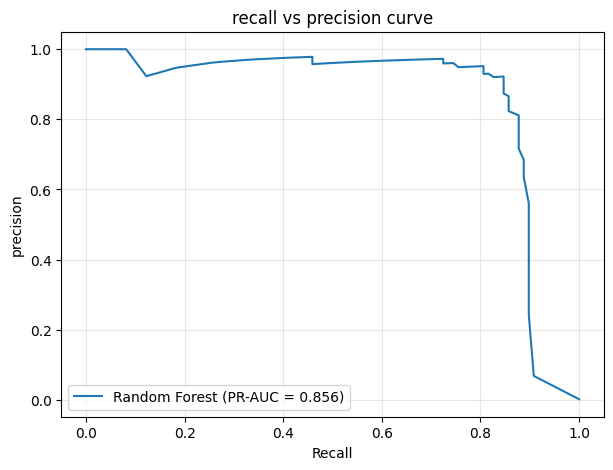

PR_AUC 0.8555650790558139


In [17]:


precision,recall ,threshold=precision_recall_curve(y_test,scores_rf)
ap_score=average_precision_score(y_test,scores_rf)

plt.figure(figsize=(7,5))
plt.plot(recall,precision,label=f"Random Forest (PR-AUC = {ap_score:.3f})")
plt.xlabel("Recall")
plt.ylabel("precision")
plt.title("recall vs precision curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("PR_AUC",ap_score)


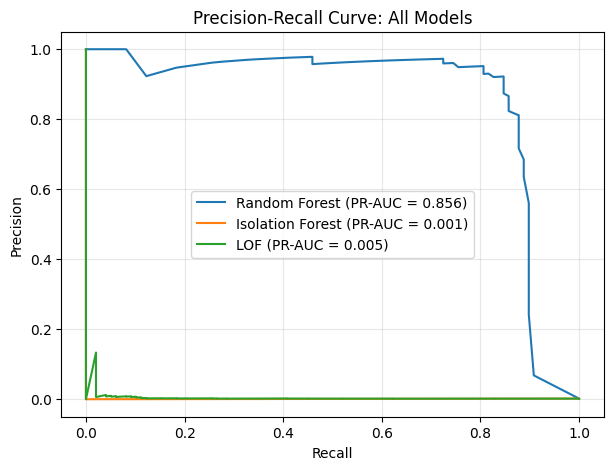

In [18]:
precisions_if, recalls_if, _ = precision_recall_curve(y_test, scores)   # Isolation Forest scores
ap_if = average_precision_score(y_test, scores)

precisions_lof, recalls_lof, _ = precision_recall_curve(y_test, -scores_lof)  # LOF: flip sign
ap_lof = average_precision_score(y_test, -scores_lof)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"Random Forest (PR-AUC = {ap_score:.3f})")
plt.plot(recalls_if, precisions_if, label=f"Isolation Forest (PR-AUC = {ap_if:.3f})")
plt.plot(recalls_lof, precisions_lof, label=f"LOF (PR-AUC = {ap_lof:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: All Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [19]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 577.2868020304569


In [20]:
from xgboost import XGBClassifier


xgb = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=-1, num_parallel_tree=None, random_state=42, ...)

In [21]:
y_pred_xgb = xgb.predict(X_test)
scores_xgb = xgb.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_xgb))
print()
print(classification_report(y_test, y_pred_xgb, digits=3))

[[56853    11]
 [   16    82]]

              precision    recall  f1-score   support

           0      1.000     1.000     1.000     56864
           1      0.882     0.837     0.859        98

    accuracy                          1.000     56962
   macro avg      0.941     0.918     0.929     56962
weighted avg      1.000     1.000     1.000     56962



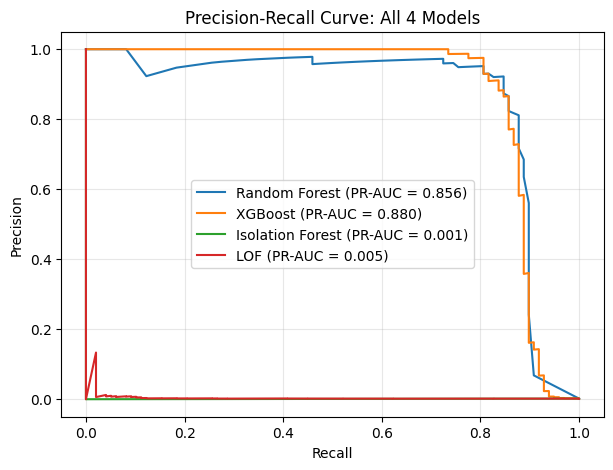

PR-AUC — RF: 0.8555650790558139 | XGB: 0.8800038893818776 | IF: 0.0008785963351518873 | LOF: 0.005217212661228434


In [22]:
precisions_xgb, recalls_xgb, _ = precision_recall_curve(y_test, scores_xgb)
ap_xgb = average_precision_score(y_test, scores_xgb)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"Random Forest (PR-AUC = {ap_score:.3f})")
plt.plot(recalls_xgb, precisions_xgb, label=f"XGBoost (PR-AUC = {ap_xgb:.3f})")
plt.plot(recalls_if, precisions_if, label=f"Isolation Forest (PR-AUC = {ap_if:.3f})")
plt.plot(recalls_lof, precisions_lof, label=f"LOF (PR-AUC = {ap_lof:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: All 4 Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("PR-AUC — RF:", ap_score, "| XGB:", ap_xgb, "| IF:", ap_if, "| LOF:", ap_lof)

In [23]:
for t in [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]:
    preds_t=(scores_xgb>=t).astype(int)
    tp = ((preds_t == 1) & (y_test == 1)).sum()
    fp = ((preds_t == 1) & (y_test == 0)).sum()
    fn = ((preds_t == 0) & (y_test == 1)).sum()
    precision_t = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_t = tp / (tp + fn) if (tp + fn) > 0 else 0
    print(f"threshold={t:.1f}  precision={precision_t:.3f}  recall={recall_t:.3f}  caught={tp}/98  false_alarms={fp}")

threshold=0.1  precision=0.778  recall=0.857  caught=84/98  false_alarms=24
threshold=0.2  precision=0.848  recall=0.857  caught=84/98  false_alarms=15
threshold=0.3  precision=0.857  recall=0.857  caught=84/98  false_alarms=14
threshold=0.4  precision=0.865  recall=0.847  caught=83/98  false_alarms=13
threshold=0.5  precision=0.882  recall=0.837  caught=82/98  false_alarms=11
threshold=0.6  precision=0.882  recall=0.837  caught=82/98  false_alarms=11
threshold=0.7  precision=0.891  recall=0.837  caught=82/98  false_alarms=10
threshold=0.8  precision=0.901  recall=0.837  caught=82/98  false_alarms=9
threshold=0.9  precision=0.909  recall=0.816  caught=80/98  false_alarms=8


In [24]:
precisions_xgb, recalls_xgb, thresholds_xgb = precision_recall_curve(y_test, scores_xgb)

target_recall = 0.90
valid_idx = np.where(recalls_xgb[:-1] >= target_recall)[0]
best_idx = valid_idx[np.argmax(precisions_xgb[valid_idx])]

chosen_threshold = thresholds_xgb[best_idx]
print("Chosen threshold:", chosen_threshold)
print("At this threshold -> precision:", precisions_xgb[best_idx], "recall:", recalls_xgb[best_idx])

Chosen threshold: 0.0005491828
At this threshold -> precision: 0.16270566727605118 recall: 0.9081632653061225


In [25]:
final_preds = (scores_xgb >= chosen_threshold).astype(int)
print(confusion_matrix(y_test, final_preds))
print()
print(classification_report(y_test, final_preds, digits=3))

[[56406   458]
 [    9    89]]

              precision    recall  f1-score   support

           0      1.000     0.992     0.996     56864
           1      0.163     0.908     0.276        98

    accuracy                          0.992     56962
   macro avg      0.581     0.950     0.636     56962
weighted avg      0.998     0.992     0.995     56962



In [26]:
practical_threshold=0.2
final_preds_practical=(scores_xgb>=practical_threshold).astype(int)
print(confusion_matrix(y_test,final_preds_practical))
print()
print(classification_report(y_test,final_preds_practical))

[[56849    15]
 [   14    84]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.86      0.85        98

    accuracy                           1.00     56962
   macro avg       0.92      0.93      0.93     56962
weighted avg       1.00      1.00      1.00     56962



In [27]:


summary = pd.DataFrame({
    "Model": ["Isolation Forest", "LOF", "Random Forest", "XGBoost (default 0.5)", "XGBoost (threshold=0.2)"],
    "Type": ["Unsupervised", "Unsupervised", "Supervised", "Supervised", "Supervised"],
    "Precision": [0.34, 0.02, 0.961, 0.882, 0.85],
    "Recall": [0.31, 0.02, 0.745, 0.837, 0.86],
    "PR-AUC": [0.001, 0.005, 0.856, 0.880, 0.880],
})
print(summary.to_string(index=False))

                  Model         Type  Precision  Recall  PR-AUC
       Isolation Forest Unsupervised      0.340   0.310   0.001
                    LOF Unsupervised      0.020   0.020   0.005
          Random Forest   Supervised      0.961   0.745   0.856
  XGBoost (default 0.5)   Supervised      0.882   0.837   0.880
XGBoost (threshold=0.2)   Supervised      0.850   0.860   0.880


In [28]:
X_train_normal = X_train[y_train == 0]
print(X_train_normal.shape)

(227451, 30)


In [29]:
n_features = X_train_normal.shape[1]

autoencoder = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(20, activation="relu"),
    layers.Dense(10, activation="relu"),   # <- the bottleneck
    layers.Dense(20, activation="relu"),
    layers.Dense(n_features, activation="linear")
])

autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           620 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │           630 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,680 (6.56 KB)

 Trainable params: 1,680 (6.56 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=20,
    batch_size=256,
    validation_split=0.1,
    shuffle=True,
    verbose=1
)

Epoch 1/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 1s 442us/step - loss: 0.8978 - val_loss: 0.3915
Epoch 2/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 364us/step - loss: 0.3655 - val_loss: 0.2959
Epoch 3/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - loss: 0.2883 - val_loss: 0.2540
Epoch 4/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 363us/step - loss: 0.2567 - val_loss: 0.2344
Epoch 5/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - loss: 0.2336 - val_loss: 0.2159
Epoch 6/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 362us/step - loss: 0.2191 - val_loss: 0.2074
Epoch 7/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 366us/step - loss: 0.2112 - val_loss: 0.2126
Epoch 8/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - loss: 0.2088 - val_loss: 0.2009
Epoch 9/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - loss: 0.2095 - val_loss: 0.1987
Epoch 10/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - loss: 0.2059 - val_loss: 0.2009
Epoch 11/20
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 361us/step - loss: 0.2067 - val_loss: 0.1955
Epoch 12/20
800/800 ━━━━━━━━━━

In [31]:
X_test_reconstructed = autoencoder.predict(X_test)
reconstruction_error = np.mean(np.square(X_test.values - X_test_reconstructed), axis=1)

print(reconstruction_error[:10])

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 0s 192us/step
[0.05993864 0.18182244 0.31099604 0.05526015 0.10044025 0.07027531
 0.13192594 0.11208565 0.09114299 0.14523579]


In [32]:
print("Normal reconstruction error (mean):", reconstruction_error[y_test == 0].mean())
print("Fraud reconstruction error (mean):", reconstruction_error[y_test == 1].mean())

Normal reconstruction error (mean): 0.21632218003827225
Fraud reconstruction error (mean): 18.209389530132917


In [33]:
ap_ae = average_precision_score(y_test, reconstruction_error)
precisions_ae, recalls_ae, _ = precision_recall_curve(y_test, reconstruction_error)

print("Autoencoder PR-AUC:", ap_ae)

Autoencoder PR-AUC: 0.49206007037180904


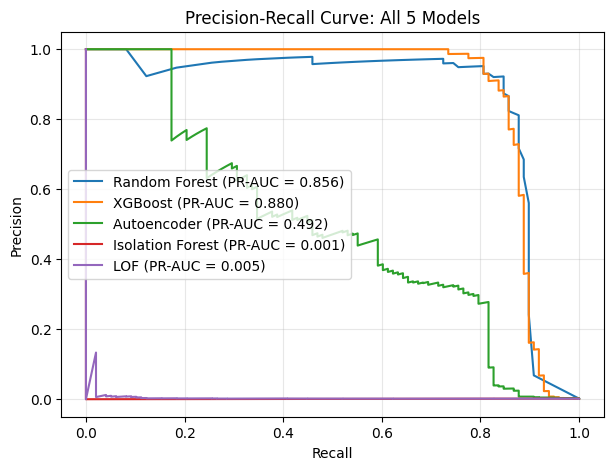

In [35]:
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"Random Forest (PR-AUC = {ap_score:.3f})")
plt.plot(recalls_xgb, precisions_xgb, label=f"XGBoost (PR-AUC = {ap_xgb:.3f})")
plt.plot(recalls_ae, precisions_ae, label=f"Autoencoder (PR-AUC = {ap_ae:.3f})")
plt.plot(recalls_if, precisions_if, label=f"Isolation Forest (PR-AUC = {ap_if:.3f})")
plt.plot(recalls_lof, precisions_lof, label=f"LOF (PR-AUC = {ap_lof:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve: All 5 Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [36]:
import joblib

joblib.dump(xgb, "../src/xgb_model.pkl")

X_test.to_csv("../data/processed/X_test_for_app.csv", index=False)
y_test.to_csv("../data/processed/y_test_for_app.csv", index=False)